In [6]:
import numpy as np
import matplotlib.pyplot as plt
import RF_Track as rft
from scipy.optimize import minimize, curve_fit
from partrec_gaussian_optimiser_utils import partrec_gaussian_optimiser_utils
from topasToDose import getDosemap
from uniformity_fit import *
from partrec_foil_plotting import partrec_foil_plotting
from RF_track_utils import *
from flatness import *
from YAG_RCF_analysis import *
import os
import csv
from topasToDose import BinnedResult

In [3]:
def get_s2_params(max_radius, max_thickness, N_slices, convolution_factor):
    s2_sigma = max_radius / 2
    step = max_radius / N_slices

    # Radial positions
    x = np.arange(-(max_radius + step), 0, step=step)

    # Thickness profile
    y = norm.pdf(x, 0, s2_sigma * convolution_factor)
    y = y - np.min(y)
    y *= max_thickness / np.max(y)
    # plt.scatter(x, y)
    slice_widths = np.diff(y) #thicknesses of each slice in L
    slice_radii = np.abs(x[1:])   # Corresponding radii (height)

    return slice_radii, slice_widths
            

In [4]:

# s2_r = [6.5, 4.9, 3.3, 1.6]
# s2_l = [1.4,2.9,4.4,4.3]

s2_r = [5.7  , 4.3, 2.9 , 1.4]
s2_l = [1 , 2. , 3, 3]

s2_r, s2_l = get_s2_params(11,38, 4,1)
print('diameter of s2: ', 2*s2_r)
print('length of s2: ', s2_l)

diameter of s2:  [22.  16.5 11.   5.5]
length of s2:  [ 4.1417876   8.57905608 12.77353046 12.50562586]


In [11]:

mass = rft.electronmass    # particle mass in MeV/c^2
population = 10 * rft.nC               # number of particles per bunch                         # particle charge in e units
P_ref = 200
N_particles = int(1e6)
charge = -1


# x, y, xp, yp = (rft.qrandn(N_particles, 4) * [1, 1, 0.01, 0.01]).T


# P = np.ones(N_particles) * P_ref
# T = np.zeros(N_particles)
# matrix = np.column_stack((x, xp, y, yp, T, P)) #transpose to match Bunch6d format
# B0 = rft.Bunch6d(mass, N_particles, charge, matrix)

Twiss = rft.Bunch6d_twiss()

if P_ref == 150:
    Twiss.beta_x = 43.6        # m
    Twiss.beta_y = 43.6      # m
    Twiss.emitt_x = 17.3/1000 * (P_ref / mass)    # mm.mrad normalised emittance
    Twiss.emitt_y = 12.3/1000 * (P_ref / mass)     # mm.mrad

elif P_ref == 200:
    Twiss.beta_x = 60        # m
    Twiss.beta_y = 80      # m
    Twiss.emitt_x = 6.75    # mm.mrad normalised emittance
    Twiss.emitt_y = 6.75     # mm.mrad    

elif P_ref == 250:
    Twiss.beta_x = 72.6        # m
    Twiss.beta_y = 72.6      # m 
    Twiss.emitt_x = 6.75    # mm.mrad normalised emittance
    Twiss.emitt_y = 6.75     # mm.mrad


# Twiss.sigma_t = 10 * RF_Track.ps       # mm/c   or 37 * RF_Track.ps
# Twiss.sigma_pt = 10     # permille
Twiss.mean_xp = 0.0
Twiss.mean_yp = 0.0

B0 = rft.Bunch6d_QR(mass, population, charge, P_ref, Twiss, N_particles)      








In [7]:
best_seen = [np.inf, None]



def loss (params, B0, target_size=16):  #16 target good for 10mm, 6 good for 5mm
    s1_l, s2_width, s2_depth = params
    '''params dimensions in mm'''
    lattice = rft.Lattice()
    window = rft.Absorber(250e-6,'beryllium')
    window.disable_energy_straggling()
    window.set_shape ('circular', 0.5,0.5 )
    lattice.append(window)
    lattice.append(rft.Drift(0.5))  #drift to s1
    
    S1 = rft.Absorber(s1_l/1000,8.897, 13,26.982,2.7, 166)
# S1 = rft.Absorber(0.0001,'air')
    S1.disable_energy_straggling()
    S1.set_shape ('circular', 1,1  )
    
    lattice.append(S1)
    

    lattice.append(rft.Drift(0.5))  #drift to S2
    # lattice.append(rft.Drift(0.532))  #drift to S2

    s2_r,s2_l = get_s2_params(s2_width, s2_depth, 4, 1)
  
    for i in range(len(s2_l)):
        Slice = rft.Absorber(s2_l[i]/1000,31.9, 37, 288.31,1.32,-1)
        Slice.disable_energy_straggling()
        Slice.set_shape ('circular',  abs(s2_r[i])/1000,abs(s2_r[i])/1000 )
        # Slice.set_shape ('circular', 2,2 )
        lattice.append(Slice)

    lattice.append(rft.Drift(0.5))  #drift to phsp
    # lattice.append(rft.Drift(2.204))

    B1 = lattice.track(B0)
    M = B1.get_phase_space('%x %xp %y %yp %E %z')
   
    x = M[:,0]
    y = M[:,2]
    count = np.sum(x**2 + y**2 < 10**2)
    transmission_10mm = count / len(x)
    

    # loss = flatness(hist_x) + flatness(hist_y)
    # loss = merit_beam_Uniform(B1, 5, 20, transmission=0.998)
    masked_x, masked_y = mask2d(M[:,0],M[:,2])
    


    # loss = abs(params_x[1]/params_x[2] -1.1)  + abs(params_y[1]/params_y[2] -1.1) #x0/sigma  
    # loss = loss_2gauss(hist_x, bin_centers_x, hist_y, bin_centers_y)
   
    # print(f'masked_x_range:{max(masked_x)},{min(masked_x)}, masked_y_range:{max(masked_y)},{min(masked_y)}'),   
    loss = nearest_neighbor_test(masked_x,masked_y)[2] # + (1-transmission_10mm)*0.1
   
    # print(f'masked_x_range:{max(masked_x)},{min(masked_x)}, masked_y_range:{max(masked_y)},{min(masked_y)}'),   
    # loss = nearest_neighbor_test(masked_x,masked_y)[2] + 0.5 * abs(masked_x.max()/target_size-1) #+ abs(len(M))/int(B0.get_population()) - 1))
    print('nn contribution:', nearest_neighbor_test(masked_x,masked_y)[2])
    print('size contribution:', abs(masked_x.max()/target_size-1))
    print('x range:',max(masked_x),min(masked_x),'y range:', max(masked_y),min(masked_y))
    # slice_width = 1
    if loss < best_seen[0]:
        best_seen[0] = loss
        best_seen[1] = params.copy()

    print('loss:', loss, 's1_l:', s1_l, 's2_2r:', s2_width, 's2_l:', s2_depth)
    return loss



In [ ]:
best_seen = [np.inf, None]



def loss (params, B0, target_size=12):  #16 target good for 10mm, 6 good for 5mm
    s1_l, s2_width, s2_depth = params
    '''params dimensions in mm'''
    lattice = rft.Lattice()
    window = rft.Absorber(250e-6,'beryllium')
    window.disable_energy_straggling()
    window.set_shape ('circular', 0.5,0.5 )
    lattice.append(window)
    lattice.append(rft.Drift(0.5))  #drift to s1
    
    S1 = rft.Absorber(s1_l/1000,8.897, 13,26.982,2.7, 166)
# S1 = rft.Absorber(0.0001,'air')
    S1.disable_energy_straggling()
    S1.set_shape ('circular', 1,1  )
    
    lattice.append(S1)
    

    lattice.append(rft.Drift(0.5))  #drift to S2
    # lattice.append(rft.Drift(0.532))  #drift to S2

    s2_r,s2_l = get_s2_params(s2_width, s2_depth, 4, 1)
  
    for i in range(len(s2_l)):
        Slice = rft.Absorber(s2_l[i]/1000,31.9, 37, 288.31,1.32,-1)
        Slice.disable_energy_straggling()
        Slice.set_shape ('circular',  abs(s2_r[i])/1000,abs(s2_r[i])/1000 )
        # Slice.set_shape ('circular', 2,2 )
        lattice.append(Slice)

    lattice.append(rft.Drift(0.5))  #drift to phsp
    # lattice.append(rft.Drift(2.204))

    B1 = lattice.track(B0)
    M = B1.get_phase_space('%x %xp %y %yp %E %z')
   
    x = M[:,0]
    y = M[:,2]
    count = np.sum(x**2 + y**2 < target_size**2)
    transmission_10mm = count / len(x)
    

    # loss = flatness(hist_x) + flatness(hist_y)
    # loss = merit_beam_Uniform(B1, 5, 20, transmission=0.998)
    masked_x, masked_y = mask2d(M[:,0],M[:,2])
    r = np.sqrt(x**2 + y**2)
    mask = r <= target_size*1.3
    


    slice_width = 1
    n_bins,fov  = 15,250
    phsp_xslice = M[(M[:,2] < slice_width)]
    phsp_xslice = phsp_xslice[(phsp_xslice[:,2] > -slice_width)]
    
    phsp_yslice = M[(M[:,0] < slice_width)]
    phsp_yslice = phsp_yslice[(phsp_yslice[:,0] > -slice_width)]
    
    
    hist_x, bin_edges_x = np.histogram(phsp_xslice[:,0], bins=n_bins, range=[-fov, fov])
    bin_centers_x = (bin_edges_x[:-1] + bin_edges_x[1:]) / 2
    hist_y, bin_edges_y = np.histogram(phsp_yslice[:,2], bins=n_bins, range=[-fov, fov])
    bin_centers_y = (bin_edges_y[:-1] + bin_edges_y[1:]) / 2

    p0=[np.max(hist_x),  np.mean(phsp_xslice[:,0]), np.std(phsp_xslice[:,0]), 4]
    params_x, _ = curve_fit(supergaussian1D, bin_centers_x, hist_x, p0=p0)
    params_y, _ = curve_fit(supergaussian1D, bin_centers_y, hist_y, p0=p0) 
    
    r90_x = x90(params_x[2], params_x[3])
    r90_y = x90(params_y[2], params_y[3])
    # loss = abs(params_x[1]/params_x[2] -1.1)  + abs(params_y[1]/params_y[2] -1.1) #x0/sigma  
    # loss = loss_2gauss(hist_x, bin_centers_x, hist_y, bin_centers_y)
   
    # print(f'masked_x_range:{max(masked_x)},{min(masked_x)}, masked_y_range:{max(masked_y)},{min(masked_y)}'),   
    # loss = nearest_neighbor_test(masked_x,masked_y)[2] + abs(masked_x.max()/target_size-1)
    # loss = nearest_neighbor_test(x[mask],y[mask])[2] + 2*abs(1-r90_x/target_size) + abs(1-r90_y/target_size) + (1-transmission_10mm)*0.1
   
    # print(f'masked_x_range:{max(masked_x)},{min(masked_x)}, masked_y_range:{max(masked_y)},{min(masked_y)}'),   
    loss = nearest_neighbor_test(masked_x,masked_y)[2] + 0.5 * abs(masked_x.max()/target_size-1) #+ abs(len(M))/int(B0.get_population()) - 1))
    print('nn contribution:', nearest_neighbor_test(masked_x,masked_y)[2])
    print('size contribution:', abs(masked_x.max()/target_size-1))
    print('x range:',max(masked_x),min(masked_x),'y range:', max(masked_y),min(masked_y))
    # slice_width = 1
    if loss < best_seen[0]:
        best_seen[0] = loss
        best_seen[1] = params.copy()

    print('loss:', loss, 's1_l:', s1_l, 's2_2r:', s2_width, 's2_l:', s2_depth)
    return loss

In [122]:
# B0_opt = rft.Bunch6d(mass, 10000, charge, matrix)
B0_opt = rft.Bunch6d_QR(mass, population, charge, P_ref, Twiss, 10000) 
rng = np.random.default_rng(12345)
x0 = rng.uniform(
    low=[0.01, 0.01, 0.01],
    high=[5, 10, 10]
)

# x0 = [ 2,  6.3, 11.9]

opt_loss = np.inf
best_seen = [np.inf, None]

for i in range(1):
    res = minimize(loss,
                      x0=x0, args=(B0_opt,),
                      bounds=[ (0.01,5),(0.01,20),(0.01,20)], #absorber thickness 0 breaks rf track
                      method='Powell',
                      options={'disp': True
                               , 'xtol':0.01}
                    #   tol=1e-2
                      )
    if res.fun < opt_loss:
        opt_loss = res.fun
        opt_params = res.x

print(f'opt_loss={opt_loss:.3f}, params, ={opt_params}')
print('best seen:', best_seen)

nn contribution: 0.5254487914697874
size contribution: 0.4132762032114511
x range: 9.387580748616783 -9.359208447625445 y range: 9.375745863595757 -9.42089067761622
loss: 0.5254487914697874 s1_l: 1.1444067521111767 s2_2r: 3.1744158137004312 s2_l: 7.975680918754014
nn contribution: 0.5438929697265577
size contribution: 0.2637595688248898
x range: 11.779846898801763 -11.669586163625723 y range: 11.73296596639389 -11.78486311456537
loss: 0.5438929697265577 s1_l: 1.9160103961380246 s2_2r: 3.1744158137004312 s2_l: 7.975680918754014
nn contribution: 0.5590845986573949
size contribution: 0.05640060759174392
x range: 15.097590278532097 -15.1169966010222 y range: 15.044846871235332 -15.050741106076085
loss: 0.5590845986573949 s1_l: 3.093989603861975 s2_2r: 3.1744158137004312 s2_l: 7.975680918754014
nn contribution: 0.540823310127017
size contribution: 0.4009570533593001
x range: 9.584687146251198 -9.595921357146086 y range: 9.602830457779637 -9.594573044059283
loss: 0.540823310127017 s1_l: 1.18

In [ ]:
from scipy.optimize import differential_evolution

res = differential_evolution(
    loss,
    bounds=[(0.01,5),(0.01,20),(0.01,20)],
    args=(B0_opt,)
)

print(f'loss={res.fun:.3f}, params, ={res.x}')


In [123]:
opt_params,loss(opt_params, B0_opt)

nn contribution: 0.5277937526445173
size contribution: 0.13002547369794826
x range: 18.080407579167172 -18.117668639716264 y range: 18.06901285972622 -18.123195930717507
loss: 0.5277937526445173 s1_l: 3.7919826129106813 s2_2r: 8.444032495366919 s2_l: 15.281001129779202


(array([ 3.79198261,  8.4440325 , 15.28100113]),
 np.float64(0.5277937526445173))

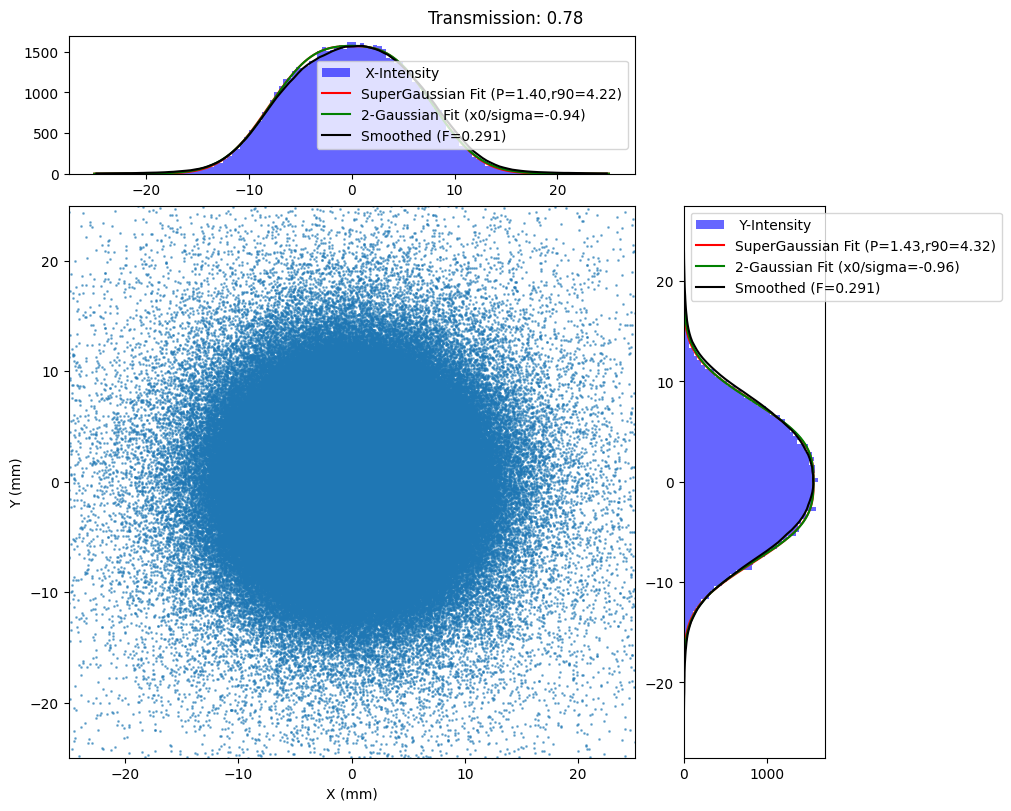

In [ ]:
# s1_l, s2_width, s2_depth = 2.27403378, 3.80651473, 4.52916474
# s1_l, s2_width, s2_depth = 4.91777743,  8.00924655, 12.33363883
# s1_l, s2_width, s2_depth = res.x
# s1_l, s2_width, s2_depth =   opt_params
# s1_l, s2_width, s2_depth = best_seen[1]
s1_l, s2_width, s2_depth = 0.7, 5.7,9

lattice = rft.Lattice()
window = rft.Absorber(250e-6,'beryllium')
window.disable_energy_straggling()
window.set_shape ('circular', 0.5,0.5 )
lattice.append(window)

lattice.append(rft.Drift(0.5))  #drift to s1

S1 = rft.Absorber(s1_l/1000,8.897, 13,26.982,2.7, 166)
# S1 = rft.Absorber(0.0001,'air')
S1.disable_energy_straggling()
S1.set_shape ('circular', 1,1 )
lattice.append(S1)

lattice.append(rft.Drift(0.5))  #drift to S2
# lattice.append(rft.Drift(0.532))  #drift to S2
s2_r,s2_l = get_s2_params(s2_width, s2_depth, 4, 1)
# s2_r =[6.5, 4.9, 3.3, 1.6]
# s2_l = [1.4, 2.9, 4.4, 4.3]

s2_r = [5.7  , 4.3, 2.9 , 1.4]
s2_l = [1 , 2. , 3, 3]

for i in range(len(s2_l)):
    Slice = rft.Absorber(s2_l[i]/1000,31.9, 37, 288.31,1.32,-1)
    Slice.disable_energy_straggling()
    Slice.set_shape ('circular',  abs(s2_r[i])/1000,abs(s2_r[i])/1000 )
    lattice.append(Slice)

lattice.append(rft.Drift(0.5))  #drift to phsp
# lattice.append(rft.Drift(0.5))

B1 = lattice.track(B0)
T = lattice.get_transport_table(
'%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')
M = B1.get_phase_space('%x %xp %y %yp %E %z')
x = M[:,0]
y = M[:,2]
count = np.sum(x**2 + y**2 < 10**2)
transmission_10mm = count / len(x)
plot_phsp(T,M,120,25,title="Transmission: "+str(round(transmission_10mm,3)))

In [ ]:
#find twiss just before s1
lattice = rft.Lattice()
window = rft.Absorber(250e-6,'beryllium')
window.disable_energy_straggling()
window.set_shape ('circular', 0.5,0.5 )
lattice.append(window)

lattice.append(rft.Drift(0.5))  #drift to s1

B1 = lattice.track(B0)
T = lattice.get_transport_table(
'%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')
M = B1.get_phase_space('%x %xp %y %yp %E %z')

def emittance(x, px):
    x = x - np.mean(x)
    px = px - np.mean(px)
    x_sqmean = np.mean(x**2) 
    px_sqmean = np.mean(px**2) 
    xpx_sqmean = (np.mean(x * px ))**2
    return np.sqrt(x_sqmean * px_sqmean - xpx_sqmean)

emm_geo_x = emittance(M[:,0], M[:,1])
emm_geo_y = emittance(M[:,2], M[:,3])

beta_x = emm_geo_x /np.std(M[:,0])**2
beta_y = emm_geo_y /np.std(M[:,2])**2
print(beta_x, beta_y, emm_geo_x, emm_geo_y)
print(T[-1])

0.9389681937633334 0.8758576956974514 2.1557482937515267 1.8134540939196644
[ 0.50025     1.06480205  1.14150766 -1.43005232 -1.69195687  1.51521416
  1.43892097  2.45378788  2.4497762 ]


In [12]:
Twiss = rft.Bunch6d_twiss()

if P_ref == 150:
    Twiss.beta_x = 1.08        # m
    Twiss.beta_y = 1.17     # m
    Twiss.alpha_x = -1.51
    Twiss.alpha_y = -1.79 #emittance not conserved
    Twiss.emitt_x = emm_geo_x * (P_ref / mass)    # mm.mrad geometric emittance
    Twiss.emitt_y = emm_geo_y * (P_ref / mass)     #
    
elif P_ref == 200:
    Twiss.beta_x = 1.01        # m
    Twiss.beta_y = 1.04      # m
    Twiss.alpha_x = -0.856
    Twiss.alpha_y = -0.752 #emittance not conserved
    Twiss.emitt_x = emm_geo_x * (P_ref / mass)    # mm.mrad geometric emittance
    Twiss.emitt_y = emm_geo_y * (P_ref / mass)     #
elif P_ref == 250:
    Twiss.beta_x = 1.05      # m
    Twiss.beta_y = 1.04      # m 
    Twiss.alpha_x = -0.725
    Twiss.alpha_y = -0.759 #emittance not conserved
    Twiss.emitt_x = emm_geo_x * (P_ref / mass)    # mm.mrad geometric emittance
    Twiss.emitt_y = emm_geo_y * (P_ref / mass)     #

B0 = rft.Bunch6d_QR(mass, population, charge, P_ref, Twiss, N_particles) 

s1_l, s2_width, s2_depth = 4.6, 5.7,9
lattice = rft.Lattice()

S1 = rft.Absorber(s1_l/1000,8.897, 13,26.982,2.7, 166)
# S1 = rft.Absorber(0.0001,'air')
S1.disable_energy_straggling()
S1.set_shape ('circular', 1,1 )
lattice.append(S1)

lattice.append(rft.Drift(0.5))  #drift to S2
# lattice.append(rft.Drift(0.532))  #drift to S2
# s2_r,s2_l = get_s2_params(s2_width, s2_depth, 4, 1)
# s2_r =[6.5, 4.9, 3.3, 1.6]
# s2_l = [1.4, 2.9, 4.4, 4.3]

s2_r = [5.7  , 4.3, 2.9 , 1.4]
s2_l = [1 , 2. , 3, 3]

for i in range(len(s2_l)):
    Slice = rft.Absorber(s2_l[i]/1000,31.9, 37, 288.31,1.32,-1)
    Slice.disable_energy_straggling()
    Slice.set_shape ('circular',  abs(s2_r[i])/1000,abs(s2_r[i])/1000 )
    lattice.append(Slice)



lattice.append(rft.Drift(0.5))  #drift to phsp
# lattice.append(rft.Drift(0.5))

B1 = lattice.track(B0)
T = lattice.get_transport_table(
'%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')
M = B1.get_phase_space('%x %xp %y %yp %E %z')
x = M[:,0]
y = M[:,2]
count = np.sum(x**2 + y**2 < 10**2)
transmission_10mm = count / len(x)
plot_phsp(T,M,120,25,title="Transmission: "+str(round(transmission_10mm,3)))

NameError: name 'emm_geo_x' is not defined

In [28]:
print(T[-1])
np.std(x),np.std(y)
I = B1.get_info()
I.beta_x

[ 1.0142      3.79677338  3.84178965 -4.03851888 -4.08024892 15.8748661
 16.22108422 17.36553054 17.6467313 ]


3.7967733794660443

In [ ]:
loss(opt_params, B0, target_size=7.5)

checking results

In [ ]:
# B0.get_population()
len(M)

checking with TOPAS

In [13]:
#twiss to 6d params
if P_ref == 150:
    Twiss.beta_x = 43.6        # m
    Twiss.beta_y = 43.6      # m
    geo_emitt_x = 22.9/1000
    geo_emitt_y = 22.9/1000

elif P_ref == 200:
    Twiss.beta_x = 60        # m
    Twiss.beta_y = 80      # m
    geo_emitt_x = 17.3/1000
    geo_emitt_y = 12.3/1000

    Twiss.beta_x = 43.9        # m
    Twiss.beta_y = 52      # m
    geo_emitt_x = 22.8/1000
    geo_emitt_y = 19.2/1000

    

elif P_ref == 250:
    Twiss.beta_x = 72.6        # m
    Twiss.beta_y = 72.6      # m 
    geo_emitt_x = 13.8/1000
    geo_emitt_y = 13.8/1000

    Twiss.beta_x = 493       # m
    Twiss.beta_y = 72.5      # m
    geo_emitt_x = 2/1000
    geo_emitt_y = 13.8/1000

Twiss.alpha_x = 0
Twiss.alpha_y = 0


beta_gamma = P_ref / mass

Twiss.emitt_x = geo_emitt_x * beta_gamma    # mm.mrad normalised emittance
Twiss.emitt_y = geo_emitt_y* beta_gamma     # mm.mrad

sig_x = np.sqrt(Twiss.beta_x * geo_emitt_x)
sig_y = np.sqrt(Twiss.beta_y * geo_emitt_y)
sig_xp = max(0.01, abs(Twiss.alpha_x * np.sqrt(geo_emitt_x / Twiss.beta_x)))
sig_yp = max(0.01,abs( Twiss.alpha_y * np.sqrt(geo_emitt_y / Twiss.beta_y)))
print('sig_x:', sig_x, 'sig_y:', sig_y, 'sig_xp:', sig_xp, 'sig_yp:', sig_yp)
beta_gamma

sig_x: 1.00045989424864 sig_y: 0.9991996797437437 sig_xp: 0.01 sig_yp: 0.01


391.39023671183674

In [ ]:

# if P_ref == 150:
#     Twiss.beta_x = 1.08        # m
#     Twiss.beta_y = 1.17     # m
#     Twiss.alpha_x = -1.51
#     Twiss.alpha_y = -1.79 #emittance not conserved
#     Twiss.emitt_x = emm_geo_x * (P_ref / mass)    # mm.mrad geometric emittance
#     Twiss.emitt_y = emm_geo_y * (P_ref / mass)     #
# elif P_ref == 200:
#     Twiss.beta_x = 1.01        # m
#     Twiss.beta_y = 1.04      # m
#     Twiss.alpha_x = -0.856
#     Twiss.alpha_y = -0.752 #emittance not conserved
#     Twiss.emitt_x = emm_geo_x * (P_ref / mass)    # mm.mrad geometric emittance
#     Twiss.emitt_y = emm_geo_y * (P_ref / mass)     #

# elif P_ref == 250:
#     Twiss.beta_x = 1.05      # m
#     Twiss.beta_y = 1.04      # m 
#     Twiss.alpha_x = -0.725
#     Twiss.alpha_y = -0.759 #emittance not conserved
#     Twiss.emitt_x = emm_geo_x * (P_ref / mass)    # mm.mrad geometric emittance
#     Twiss.emitt_y = emm_geo_y * (P_ref / mass)     #


# sig_x = np.sqrt(Twiss.beta_x * geo_emitt_x)
# sig_y = np.sqrt(Twiss.beta_y * geo_emitt_y)
# sig_xp = max(0.01, abs(Twiss.alpha_x * np.sqrt(emm_geo_x / Twiss.beta_x)))
# sig_yp = max(0.01, abs(Twiss.alpha_y * np.sqrt(emm_geo_y / Twiss.beta_y)))
# print('sig_x:', sig_x, 'sig_y:', sig_y, 'sig_xp:', sig_xp, 'sig_yp:', sig_yp)

# sig_x = 1.235
# sig_y = 1.257
# sig_xp = 1.446
# sig_yp = 1.51


NameError: name 'emm_geo_x' is not defined

In [15]:
output_filename='CLARA_200B_full'
dose_depth=83
dir = '/Users/sabrinawang/Desktop/DPhil_Project/'
profile = "dose"
N_particles = int(1e6)  

# s1_l, s2_width, s2_depth = 2.27403378, 3.80651473, 4.52916474 '''works great'''
# s1_l, s2_width, s2_depth = opt_params
# s1_l, s2_width, s2_depth = best_seen[1]
# s1_l, s2_width, s2_depth = res.x
# s1_l, s2_width, s2_depth =  1.5,3.9,4
s1_l, s2_width, s2_depth =  2, 5.7,9 #s1 2 or 4.6mm for 200 and 250MeV

setup = partrec_gaussian_optimiser_utils(world_material="Air")

setup.generate_phsp_beam(sig_x,sig_y,sig_xp,sig_yp,P_ref,0,N_particles)

setup.add_cylinder("window",0.25,0,500,"G4_Be",298.5)
s1_pos = 500 + 298.5
setup.add_flat_scatterer(s1_l,"Aluminum",s1_pos)

# setup.add_gaussian_scatterer(s2_depth,s2_width,1,4,"PEEK",1001)




# constructing s2 from slices
s2_r = [5.7  , 4.3, 2.9 , 1.4]
s2_l = [1 , 2. , 3, 3]

for i in range(len(s2_l)):
    sname = 'S2_slice_'+str(i)
    slice_position = s1_pos + 500 + sum(s2_l[:i-1]) #532 is distance from s1 end to s2 start
    setup.add_cylinder(sname, s2_l[i-1],0, s2_r[i-1], 'PEEK', slice_position)

setup.add_cylinder('kapton',0.25, 0,33,"kapton",s1_pos+500+sum(s2_l))

setup.add_cylinder('tank_edge',0.8, 0,100,"PMMA",s1_pos + 999)

if profile == "dose":
    setup.add_tank_bins(s1_pos + 1000, dose_depth, 100,100,dose_depth,output_filename,width=44)
elif profile == "intensity":
    # setup.add_patient(1191)
    setup.add_patient(s1_pos + 1000)

setup.run_topas(view_setup=False)



Welcome to TOPAS, Tool for Particle Simulation (Version 3.9)
Loading parameters starting from: /Users/sabrinawang/Desktop/DPhil_Project/topas_main.txt

Geant4 Data directory has been specified by the
TOPAS_G4_DATA_DIR environment variable as /Applications/G4Data

**************************************************************
 Geant4 version Name: geant4-10-07-patch-03 [MT]   (19-November-2021)
  << in Multi-threaded mode >> 
                       Copyright : Geant4 Collaboration
                      References : NIM A 506 (2003), 250-303
                                 : IEEE-TNS 53 (2006), 270-278
                                 : NIM A 835 (2016), 186-225
                             WWW : http://geant4.org/
**************************************************************

TOPAS is in MT mode, setting number of threads to: 8

TOPAS set the tolerances based on the World size to:
      Surface tolerance = 0.05 nm, and radial tolerance = 0.05 nm.
/opt/anaconda3/envs/RFT_topas_bdsim/s

In [ ]:
def get_bin_edges(dim):
    return np.linspace(0, dim.n_bins * dim.bin_width, dim.n_bins + 1)

chargenC = 50
csv_path = "CLARA_experiments/200B_full.csv"
fig_dir = "CLARA_output_figs"
# dose_file = "DoseAtTank"+str(dose_depth)+ "_"+ output_filename+".csv"
dose_file = "DoseAtTank83_"+output_filename + ".csv"

os.makedirs(fig_dir, exist_ok=True)

existing_csv_entries = set()

if os.path.exists(csv_path):
    with open(csv_path, "r", newline="") as f:
        reader = csv.reader(f)
        next(reader, None)  # skip header
        for row in reader:
            if row:
                existing_csv_entries.add(round(float(row[0]), 1))

write_header = not os.path.exists(csv_path) or os.path.getsize(csv_path) == 0

with open(csv_path, "a", newline="") as f:
    writer = csv.writer(f)

    if write_header:
        writer.writerow([
            "depth",
            "cx", "cy",
            "dose_centre",
            "P_x", "P_y",
            "r90_x", "r90_y",
            "ratio_x", "ratio_y",
            "dose_std",
            "errPx", "errPy",
            "err_x90_x","err_x90_y",
            "err_ratio_x", "err_ratio_y"
        ])
    

    # peek at the scorer to see if it's multibin in z (depth)
    _raw = BinnedResult(dose_file).data['Sum']
    nz = _raw.shape[2] if _raw.ndim == 3 else 1
    print(nz)
    if nz > 1:
        z_dim = BinnedResult(dose_file).dimensions[2]
        depths = (get_bin_edges(z_dim)[1:] * 10)[::-1]  # back edge of each bin, mm, same length as bin centres
        for i in range(nz):
            depth_i = round(float(depths[i]), 1)
            csv_line_exists = depth_i in existing_csv_entries

            if csv_line_exists:
                print(f"Skipping {depth_i}: CSV entry and image already exist.")
                continue

            x, y, doseMap = getDosemap(
                dose_file, N_particles, dose_depth=depths[i],
                outputFileName=output_filename, acChargenC=chargenC, plot=False, z_index=i
            )
            fig, cx, cy, dose_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, dose_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1( doseMap, "RCF",x, y,strip_width=2)

            # plt.savefig(os.path.join(fig_dir, output_filename + f"_z{depth_i:.1f}mm_dose_map.png"))
            # plt.close(fig)

            writer.writerow([
                depth_i,
                cx, cy,
                dose_centre,
                Px, Py,
                x90_x, x90_y,
                ratio_x, ratio_y,
                dose_std,
                errPx, errPy,
                err_x90_x, err_x90_y
            ])
            existing_csv_entries.add(depth_i)

    else:
        x, y, doseMap = getDosemap(
            dose_file, N_particles, dose_depth, output_filename, acChargenC=chargenC, plot=False
        )
        fig, cx, cy, dose_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, dose_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1( doseMap, "RCF",x, y)
 


 aaaaaqetyjtht






ccdcdcd
# ymhgflkd;,v;vcdd
sadefefefefe
        writer.writerow([
            5.9,
            cx, cy,
            dose_centre,
            Px, Py,
            x90_x, x90_y,
            ratio_x, ratio_y,
            dose_std,
            errPx, errPy,
            err_x90_x, err_x90_y,
            err_ratio_x, err_ratio_y
        ])
        plt.savefig(os.path.join(fig_dir, output_filename + '_20mm_dose_map.png'))

83


In [ ]:
# #dose estimation

# output_filename='CLARA_dose_estimate'
# dose_depth=15
# dir = '/Users/sabrinawang/Desktop/DPhil_Project/'
# profile = "dose"
# N_particles = 100000

# sig_x, sig_y, sig_xp, sig_yp = 0.4, 0.4, 0.001, 0.001

# setup = partrec_gaussian_optimiser_utils(world_material="Air")

# setup.generate_phsp_beam(sig_x,sig_y,sig_xp,sig_yp,P_ref,0,N_particles)

# setup.add_cylinder("window",0.25,0,500,"G4_Be",1)

# setup.add_cylinder('tank_edge',10, 0,100,"PMMA",51)

# # 50 air+ plastic 10mm plastic 15mm water

# if profile == "dose":
#     setup.add_tank_bins(76, dose_depth, 100,100,1,output_filename,width=30)
# elif profile == "intensity":
#     # setup.add_patient(76)
#     setup.add_patient(76)

# setup.run_topas(view_setup=False)


Welcome to TOPAS, Tool for Particle Simulation (Version 3.9)
Loading parameters starting from: /Users/sabrinawang/Desktop/DPhil_Project/topas_main.txt

Geant4 Data directory has been specified by the
TOPAS_G4_DATA_DIR environment variable as /Applications/G4Data

**************************************************************
 Geant4 version Name: geant4-10-07-patch-03 [MT]   (19-November-2021)
  << in Multi-threaded mode >> 
                       Copyright : Geant4 Collaboration
                      References : NIM A 506 (2003), 250-303
                                 : IEEE-TNS 53 (2006), 270-278
                                 : NIM A 835 (2016), 186-225
                             WWW : http://geant4.org/
**************************************************************

TOPAS is in MT mode, setting number of threads to: 6

TOPAS set the tolerances based on the World size to:
      Surface tolerance = 0.05 nm, and radial tolerance = 0.05 nm.
/opt/anaconda3/envs/RFT_bdsim/share/G

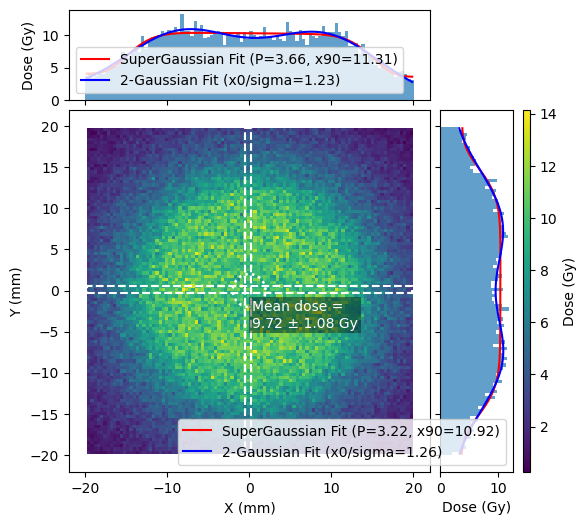

In [ ]:


# if profile == "dose":
# #             # initialise plotting class
#     # doseMap = getDosemap("DoseAtTank"+str(dose_depth)+ "_"+ output_filename+".csv",N_particles, dose_depth, output_filename, acChargenC=0.025, plot = True) 
#     # fitDoseMap(N_particles, dose_depth,output_filename)

#     x, y, doseMap = getDosemap(
#         "DoseAtTank"+str(dose_depth)+ "_"+ output_filename+".csv",N_particles, dose_depth, output_filename, acChargenC=66.7, plot=False
#     )
#     fig, new_cx_idx, new_cy_idx, dose_centre, P_x, P_y, x90_x, x90_y, ratio_x, ratio_y, err_dose, err_Px, err_Py, err_x90_x, err_x90_y ,err_ratio_x, err_ratio_y= plot_dose1( doseMap, "RCF",x, y,2)
#     # plt.savefig('Output_figs/' + output_filename + "_dose_map.png")
